**[🏠 Course Home](00_START_HERE.ipynb) | ↩️ Return to: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb)**

---

# 🛏️ Appendix: Frequentist vs. Bayesian Tolerance Intervals & Decision Sizing
### *From the Flaw of Averages to Prediction Intervals, ISO Tolerance Limits, and Asymmetric Loss*

---

## 1. Problem Framing: The Engineering & Clinical Challenge

Suppose you are the chief operations engineer for a regional healthcare system designing standard patient beds for a new 500-bed hospital wing.

You measure a calibration sample of $n = 50$ adult patient heights (the exact dataset from **Sheets 2 & 3** of the Bayesian Inference curriculum):
- **Sample Size**: $n = 50$
- **Sample Mean ($\bar{y}$)**: $170.70\text{ cm}$
- **Sample Standard Deviation ($s$)**: $7.47\text{ cm}$

The hospital board specifies an engineering requirement:
> *"How long must our beds be so that we have a rigorous statistical guarantee that incoming patients will sleep comfortably without hanging over the mattress edge?"*

In this notebook, we systematically compare **5 distinct statistical paradigms** to solve this problem:
1. **The Administrative Trap (The Flaw of Averages)**: Sizing based on the mean $\mu$ alone.
2. **The Naive Frequentist Plug-In Rule**: $\bar{y} + z_{0.99} \cdot s$.
3. **Proper Frequentist Tool #1 (The Prediction Interval)**: Guarantees for the *very next patient*.
4. **Proper Frequentist Tool #2 (The Tolerance Interval / ISO 16269-6)**: Guarantees for the *entire population*.
5. **The Bayesian Posterior Predictive Solution & Asymmetric Loss Minimization**: Integrating prior domain knowledge and real-world financial penalties.


In [1]:
import numpy as np
import scipy.stats as stats
import scipy.optimize as optimize
import matplotlib.pyplot as plt

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Generate the identical n = 50 dataset from Sheets 2 & 3
np.random.seed(42)
n = 50
heights = np.random.normal(loc=172.5, scale=8.0, size=n)

y_bar = np.mean(heights)
s = np.std(heights, ddof=1)

print(f"Dataset Initialized: n = {n}")
print(f"Sample Mean (y_bar): {y_bar:.2f} cm")
print(f"Sample Std  (s):     {s:.2f} cm")


Dataset Initialized: n = 50
Sample Mean (y_bar): 170.70 cm
Sample Std  (s):     7.47 cm


---

## 2. Method 0: The Administrative Trap (The "Flaw of Averages")

In real-world procurement and facility management, non-technical committees routinely fall into the **Flaw of Averages** (popularized by Stanford professor Sam Savage):
- A hospital committee reads the report: *"The average adult height is $170.7\text{ cm}$."*
- They reason: *"If we buy $180\text{ cm}$ beds, we have a generous safety buffer of $+9.3\text{ cm}$ above the average patient. That must be plenty safe!"*

### The Historical Warning: The 1950s Air Force Cockpit Disaster
In the 1950s, the U.S. Air Force experienced puzzlingly high crash rates in high-performance jet fighters. The cockpits had been engineered to fit the "average pilot," calculated from measurements of over 4,000 pilots across 10 physical dimensions (sitting height, chest circumference, sleeve length, etc.).

When researcher **Gilbert Daniels** analyzed the data to determine how many of the 4,000 pilots were within the middle 30% ("average") on all 10 dimensions, the result was stunning: **ZERO**. 
By designing for the average pilot, the Air Force had engineered cockpits that **properly fit no one**.

Let's quantify the hospital's operational failure rate if it builds naive $180\text{ cm}$ beds:


In [2]:
# Evaluate overflow risk for naive 180 cm bed
prob_fail_180 = 1.0 - stats.norm.cdf(180.0, loc=y_bar, scale=s)

print(f"=== Method 0: Naive Mean Bed (180 cm) ===")
print(f"Patient Overflow Probability P(Y > 180 cm): {prob_fail_180 * 100:.1f}%")
print(f"Impact: 1 in every {int(1/prob_fail_180)} patients will have their feet hanging off the mattress!")


=== Method 0: Naive Mean Bed (180 cm) ===
Patient Overflow Probability P(Y > 180 cm): 10.6%
Impact: 1 in every 9 patients will have their feet hanging off the mattress!


---

## 3. Method 1: The Naive Frequentist Plug-In Rule ($\bar{y} + z_{0.99} \cdot s$)

A savvy engineer knows not to look at the mean alone and immediately factors in the standard deviation:
$$\text{Bed Length}_{\text{Plug-In}} = \bar{y} + z_{0.99} \times s$$
For a standard Normal distribution, the 99th percentile cutoff is $z_{0.99} \approx 2.3263$.

### Why This is Overconfident (The Plug-In Fallacy):
This formula "plugs in" the sample estimates $(\bar{y}, s)$ as if they were the true, eternal parameters of nature $(\mu, \sigma)$ with zero measurement error.
- But $\bar{y}$ was calculated from only **$n = 50$ people** ($\text{SE}(\mu) \approx 1.05\text{ cm}$).
- $s$ is also a noisy sample estimate.
- Treating sample estimates as fixed truth underestimates the true spread of future data.


In [3]:
z_99 = stats.norm.ppf(0.99)
bed_plugin_99 = y_bar + z_99 * s

print(f"=== Method 1: Naive Frequentist Plug-In ===")
print(f"z-multiplier for 99%: {z_99:.4f}")
print(f"Plug-In Bed Length:   {bed_plugin_99:.2f} cm")


=== Method 1: Naive Frequentist Plug-In ===
z-multiplier for 99%: 2.3263
Plug-In Bed Length:   188.07 cm


---

## 4. Method 2: Proper Frequentist Tool #1 — The Prediction Bound (Next Single Patient)

If the hospital's clinical question is:
> *"We want a $99\%$ probability that the **very next patient** admitted to the hospital will fit comfortably in the bed."*

The proper frequentist tool is a **One-Sided Upper Prediction Bound**.

### Mathematical Derivation:
When predicting an unobserved future patient $Y_{\text{new}} \sim \text{Normal}(\mu, \sigma^2)$, the difference between the sample mean $\bar{Y}$ and $Y_{\text{new}}$ has variance:
$$\text{Var}(Y_{\text{new}} - \bar{Y}) = \text{Var}(Y_{\text{new}}) + \text{Var}(\bar{Y}) = \sigma^2 + \frac{\sigma^2}{n} = \sigma^2 \left(1 + \frac{1}{n}\right)$$

Because the true standard deviation $\sigma$ is unknown and estimated by $s$, the standardized pivot follows a **Student's $t$-distribution** with $n - 1$ degrees of freedom:
$$T = \frac{Y_{\text{new}} - \bar{Y}}{s \sqrt{1 + \frac{1}{n}}} \sim t_{n-1}$$

### The Prediction Formula:
$$\text{Bed Length}_{\text{Pred}} = \bar{y} + t_{n-1, \, 0.99} \times s \sqrt{1 + \frac{1}{n}}$$

Notice the two corrections over the naive plug-in:
1. **$t_{n-1} > z$**: The Student's $t$ critical value ($2.405$) is larger than $z$ ($2.326$) to account for uncertainty in estimating $\sigma$.
2. **$\sqrt{1 + 1/n} > 1$**: Incorporates the sampling error of the mean $\bar{y}$.


In [4]:
t_99 = stats.t.ppf(0.99, df=n - 1)
inflation_factor = np.sqrt(1.0 + 1.0 / n)
bed_pred_99 = y_bar + t_99 * s * inflation_factor

print(f"=== Method 2: Frequentist Prediction Bound (Next Single Patient) ===")
print(f"t critical value (df=49): {t_99:.4f}  (vs. z = {z_99:.4f})")
print(f"Sampling inflation sqrt(1 + 1/n): {inflation_factor:.4f}")
print(f"Prediction Bed Length:     {bed_pred_99:.2f} cm")
print(f"Difference vs Plug-In:     +{bed_pred_99 - bed_plugin_99:.2f} cm (Accounts for estimation noise)")


=== Method 2: Frequentist Prediction Bound (Next Single Patient) ===
t critical value (df=49): 2.4049  (vs. z = 2.3263)
Sampling inflation sqrt(1 + 1/n): 1.0100
Prediction Bed Length:     188.84 cm
Difference vs Plug-In:     +0.77 cm (Accounts for estimation noise)


---

## 5. Method 3: Proper Frequentist Tool #2 — Upper Tolerance Limits (ISO 16269-6 / Industrial Standard)

A hospital does not manufacture a bed for just *one* patient; it builds hundreds of beds to serve **thousands of patients over a 15-year lifecycle**.

The executive clinical board demands an industrial-grade reliability guarantee:
> *"We want **$95\%$ confidence** that **at least $99\%$ of the entire patient population** will fit in our standard beds."*

In industrial statistics and quality engineering, this is called a **$(p, 1-\gamma)$ Upper Tolerance Limit** ($p = 0.99$, confidence $1-\gamma = 0.95$).

### Mathematical Derivation via the Non-Central $t$-Distribution:
We seek a tolerance factor $k$ such that:
$$P\left( P(Y \le \bar{y} + k \cdot s) \ge p \right) = 1 - \gamma$$
This condition requires finding the quantile of a **Non-Central $t$-Distribution** with non-centrality parameter $\delta = z_p \sqrt{n}$:
$$k = \frac{t_{n-1, \, 1-\gamma, \, \delta}}{\sqrt{n}}$$

### The Tolerance Formula:
$$\text{Bed Length}_{\text{Tol}} = \bar{y} + k \times s$$


In [5]:
# Target: 95% confidence that >= 99% of population fits
p_coverage = 0.99
gamma_conf = 0.95

delta = stats.norm.ppf(p_coverage) * np.sqrt(n)
t_nct = stats.nct.ppf(gamma_conf, df=n - 1, nc=delta)
k_tol = t_nct / np.sqrt(n)

bed_tol_99 = y_bar + k_tol * s

print(f"=== Method 3: Frequentist Tolerance Limit (Entire Population) ===")
print(f"Non-centrality parameter (delta): {delta:.4f}")
print(f"Tolerance Factor (k):              {k_tol:.4f}  (vs. z = {z_99:.4f})")
print(f"Tolerance Bed Length:              {bed_tol_99:.2f} cm")
print(f"Difference vs Plug-In:             +{bed_tol_99 - bed_plugin_99:.2f} cm")


=== Method 3: Frequentist Tolerance Limit (Entire Population) ===
Non-centrality parameter (delta): 16.4498
Tolerance Factor (k):              2.8624  (vs. z = 2.3263)
Tolerance Bed Length:              192.08 cm
Difference vs Plug-In:             +4.00 cm


---

## 6. Method 4: The Bayesian Posterior Predictive Solution

In the Bayesian paradigm, we don't need distinct mathematical theorems or non-central tables for each question. 

Instead, we construct the **Posterior Predictive Distribution** $P(y_{\text{new}} \mid y)$ by integrating over our posterior parameter uncertainty:
$$P(y_{\text{new}} \mid y) = \iint P(y_{\text{new}} \mid \mu, \sigma) \, P(\mu, \sigma \mid y) \, d\mu \, d\sigma$$

### The Two Advantages of Bayesian Modeling:
1. **Incorporating Prior Domain Knowledge**:
   From historical adult anthropometry, we know human height averages around $170\text{ cm}$ with spread around $15\text{ cm}$. We specify:
   $$\mu \sim \text{Normal}(170, 15), \quad \sigma \sim \text{Uniform}(0, 30)$$
2. **Instant Forward Simulation (The 2-Stage Cascade)**:
   - Sample parameters from the Laplace approximation: $(\mu^{(s)}, \sigma^{(s)}) \sim \text{MVNormal}(\hat{\theta}_{\text{MAP}}, \Sigma)$.
   - Sample future individuals: $y_{\text{new}}^{(s)} \sim \text{Normal}(\mu^{(s)}, \sigma^{(s)})$.

Any operational specification is then evaluated by inverting the simulated predictive distribution via empirical percentiles:
$$\text{Bed Length}_{99\%} = \text{Quantile}_{0.99}(y_{\text{new}})$$


In [6]:
# 1. Define Negative Log-Posterior
def neg_log_posterior(params):
    mu, sigma = params[0], params[1]
    if sigma <= 0 or sigma >= 30: return 1e10
    log_lik = np.sum(stats.norm.logpdf(heights, loc=mu, scale=sigma))
    log_prior = stats.norm.logpdf(mu, 170, 15) + stats.uniform.logpdf(sigma, 0, 30)
    return -(log_lik + log_prior)

# 2. Find MAP Mode via Quasi-Newton (BFGS)
opt_fit = optimize.minimize(neg_log_posterior, [170.0, 10.0], method='BFGS')
map_estimates = opt_fit.x

# 3. Compute Numerical Hessian via Central Differences
eps = 1e-4
H = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        if i == j:
            xp, xm = map_estimates.copy(), map_estimates.copy()
            xp[i] += eps; xm[i] -= eps
            H[i, j] = (neg_log_posterior(xp) - 2*neg_log_posterior(map_estimates) + neg_log_posterior(xm)) / (eps**2)
        else:
            x_pp, x_pm, x_mp, x_mm = [map_estimates.copy() for _ in range(4)]
            x_pp[i] += eps; x_pp[j] += eps
            x_pm[i] += eps; x_pm[j] -= eps
            x_mp[i] += eps; x_mp[j] -= eps
            x_mm[i] -= eps; x_mm[j] -= eps
            H[i, j] = (neg_log_posterior(x_pp) - neg_log_posterior(x_pm) - neg_log_posterior(x_mp) + neg_log_posterior(x_mm)) / (4 * eps**2)

H = 0.5 * (H + H.T)
vcov_matrix = np.linalg.inv(H)

# 4. 2-Stage Posterior Predictive Simulation (10,000 future individuals)
np.random.seed(42)
quap_draws = np.random.multivariate_normal(mean=map_estimates, cov=vcov_matrix, size=10000)
pred_heights = np.random.normal(loc=quap_draws[:, 0], scale=quap_draws[:, 1])

# Extract percentiles
bed_bayes_95 = np.percentile(pred_heights, 95.0)
bed_bayes_99 = np.percentile(pred_heights, 99.0)
bed_bayes_999 = np.percentile(pred_heights, 99.9)

print(f"=== Method 4: Bayesian Posterior Predictive Distribution ===")
print(f"MAP Estimates: mu = {map_estimates[0]:.2f} cm, sigma = {map_estimates[1]:.2f} cm")
print(f"Bayesian 95% Spec:   {bed_bayes_95:.2f} cm")
print(f"Bayesian 99% Spec:   {bed_bayes_99:.2f} cm")
print(f"Bayesian 99.9% Spec: {bed_bayes_999:.2f} cm")


=== Method 4: Bayesian Posterior Predictive Distribution ===
MAP Estimates: mu = 170.69 cm, sigma = 7.39 cm
Bayesian 95% Spec:   182.88 cm
Bayesian 99% Spec:   187.55 cm
Bayesian 99.9% Spec: 192.85 cm


---

## 7. Method 5: Beyond Arbitrary Percentiles — Bayesian Decision Theory & Asymmetric Loss

In real-world engineering, asking for "99% coverage" is fundamentally arbitrary:
- Why not $98.5\%$? Why not $99.9\%$?

**The real world has an asymmetric cost structure**:
- **Building a bed $1\text{ cm}$ too long** ($L > y_{\text{new}}$): Incurs a small material & floor footprint penalty:
  $$C_{\text{over}} = 15\text{ USD/cm}$$
- **Building a bed $1\text{ cm}$ too short** ($L < y_{\text{new}}$): Incurs a severe clinical & legal penalty (patient transfers, foot ulcers, liability):
  $$C_{\text{under}} = 150\text{ USD/cm}$$

### Mathematical Derivation of Optimal Bed Length:
The economic loss for building a bed of length $L$ for a patient of height $y$ is the **asymmetric linear loss** (pinball / check loss):
$$\text{Loss}(L, y) = \begin{cases} C_{\text{under}} \cdot (y - L) & \text{if } y > L \quad (\text{Patient too tall}) \\ C_{\text{over}} \cdot (L - y) & \text{if } y \le L \quad (\text{Wasted mattress length}) \end{cases}$$

Under **Bayesian Decision Theory**, the optimal bed length $L^*$ minimizes the **Posterior Expected Loss**:
$$L^* = \arg\min_L \mathbb{E}_{y_{\text{new}} \mid y} \Big[ \text{Loss}(L, y_{\text{new}}) \Big]$$

Differentiating with respect to $L$ reveals the famous **Newsvendor / Quantile Rule**:
$$P(y_{\text{new}} \le L^*) = \frac{C_{\text{under}}}{C_{\text{under}} + C_{\text{over}}} = \frac{150}{150 + 15} = \frac{150}{165} \approx \mathbf{90.91\%}$$

The mathematically optimal bed length is precisely the **$90.91^{\text{th}}$ percentile** of the posterior predictive distribution!


In [7]:
# 1. Define Cost Parameters
c_over = 15.0    # $15 per cm of wasted space/material
c_under = 150.0  # $150 per cm of patient overflow

# 2. Optimal Theoretical Quantile
tau_star = c_under / (c_under + c_over)
optimal_bed_length = np.percentile(pred_heights, tau_star * 100.0)

# 3. Empirically evaluate expected cost across candidate bed lengths (170 to 205 cm)
candidate_lengths = np.linspace(170, 205, 150)
expected_losses = []

for l_cand in candidate_lengths:
    # Overlength cost: max(0, l_cand - y) * c_over
    # Underlength cost: max(0, y - l_cand) * c_under
    diff = pred_heights - l_cand
    loss = np.where(diff > 0, diff * c_under, -diff * c_over)
    expected_losses.append(np.mean(loss))

expected_losses = np.array(expected_losses)
emp_min_idx = np.argmin(expected_losses)

print(f"=== Method 5: Bayesian Decision Theory (Optimal Economic Sizing) ===")
print(f"Underlength Cost: ${c_under:.2f}/cm vs. Overlength Cost: ${c_over:.2f}/cm")
print(f"Optimal Quantile Ratio tau*: {tau_star * 100:.2f}%")
print(f"Analytic Optimal Bed Length: {optimal_bed_length:.2f} cm")
print(f"Empirical Grid Minimum:      {candidate_lengths[emp_min_idx]:.2f} cm (Min Expected Cost: ${expected_losses[emp_min_idx]:.2f} / patient)")


=== Method 5: Bayesian Decision Theory (Optimal Economic Sizing) ===
Underlength Cost: $150.00/cm vs. Overlength Cost: $15.00/cm
Optimal Quantile Ratio tau*: 90.91%
Analytic Optimal Bed Length: 180.53 cm
Empirical Grid Minimum:      180.57 cm (Min Expected Cost: $200.68 / patient)


---

## 8. Interactive Visual Dashboard: Comparing All Paradigms

Let us overlay all 5 decision cutoffs and inspect the economic cost curve side-by-side:


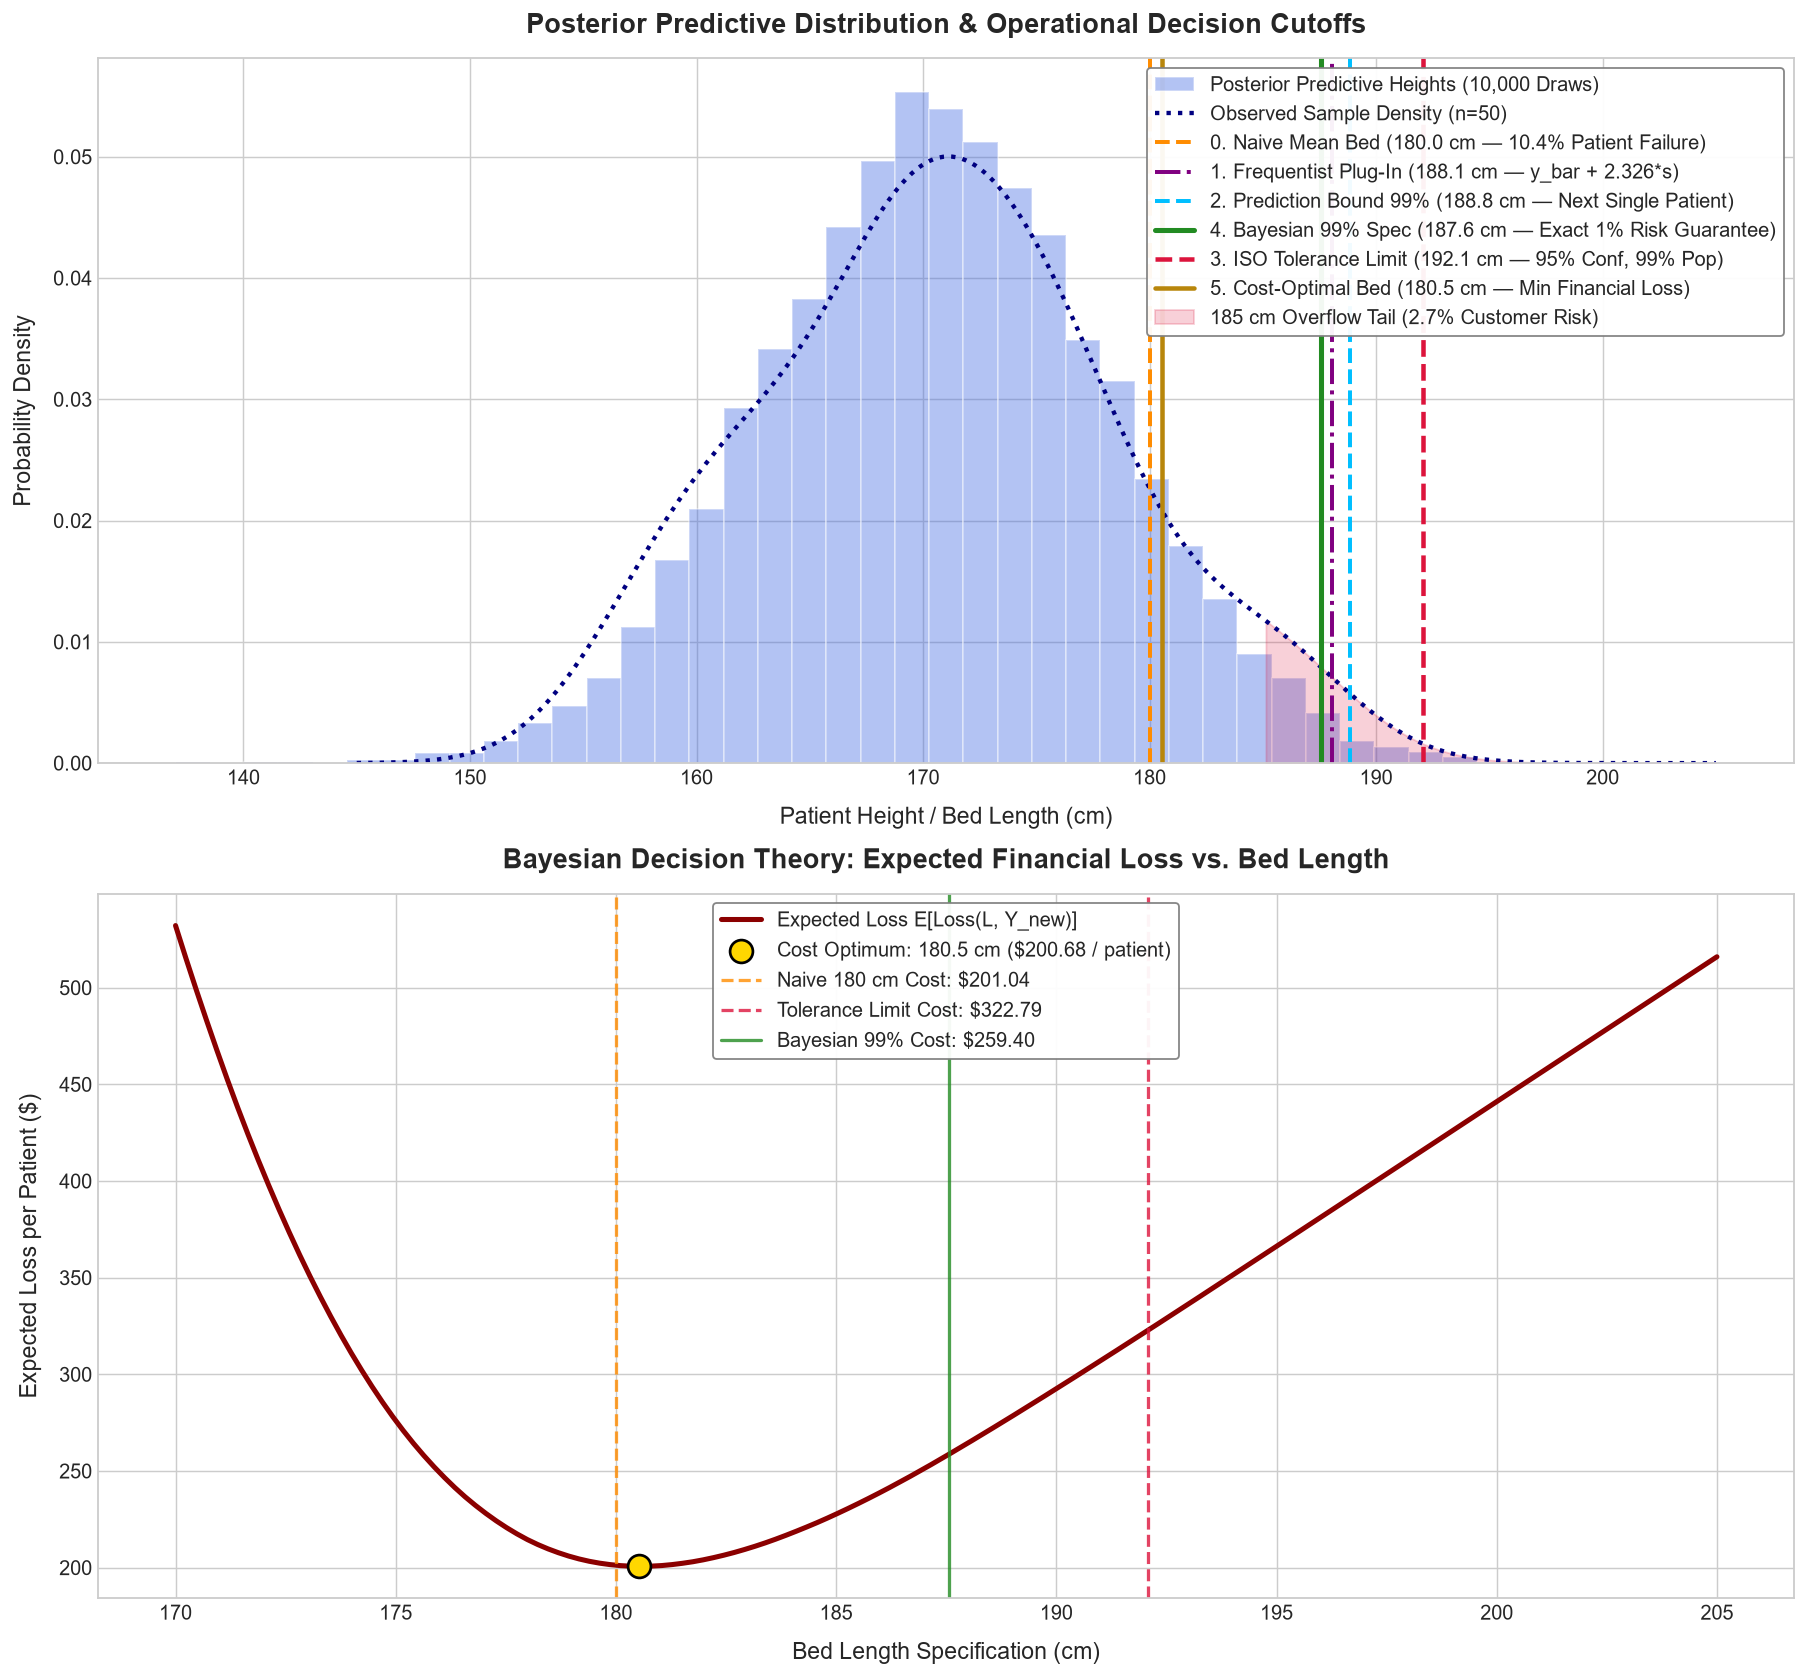

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 13), dpi=130)

# ==================== Plot 1: Predictive Distribution & Decision Cutoffs ====================
ax1.hist(pred_heights, bins=45, density=True, color='royalblue', alpha=0.4, edgecolor='white', label='Posterior Predictive Heights (10,000 Draws)')

kde = stats.gaussian_kde(heights)
x_grid = np.linspace(145, 205, 300)
ax1.plot(x_grid, kde(x_grid), color='navy', linestyle=':', lw=2.4, label='Observed Sample Density (n=50)')

# Cutoff lines with high-contrast colors and clear labels
ax1.axvline(180.0, color='darkorange', linestyle='--', lw=2.2, label='0. Naive Mean Bed (180.0 cm — 10.4% Patient Failure)')
ax1.axvline(bed_plugin_99, color='purple', linestyle='-.', lw=2.2, label=f'1. Frequentist Plug-In ({bed_plugin_99:.1f} cm — y_bar + 2.326*s)')
ax1.axvline(bed_pred_99, color='deepskyblue', linestyle='--', lw=2.2, label=f'2. Prediction Bound 99% ({bed_pred_99:.1f} cm — Next Single Patient)')
ax1.axvline(bed_bayes_99, color='forestgreen', linestyle='-', lw=2.8, label=f'4. Bayesian 99% Spec ({bed_bayes_99:.1f} cm — Exact 1% Risk Guarantee)')
ax1.axvline(bed_tol_99, color='crimson', linestyle='--', lw=2.5, label=f'3. ISO Tolerance Limit ({bed_tol_99:.1f} cm — 95% Conf, 99% Pop)')
ax1.axvline(optimal_bed_length, color='darkgoldenrod', linestyle='-', lw=2.5, label=f'5. Cost-Optimal Bed ({optimal_bed_length:.1f} cm — Min Financial Loss)')

# Shade tail risk zones
x_fill_185 = x_grid[x_grid >= 185.0]
ax1.fill_between(x_fill_185, kde(x_fill_185), color='crimson', alpha=0.2, label='185 cm Overflow Tail (2.7% Customer Risk)')

ax1.set_title("Posterior Predictive Distribution & Operational Decision Cutoffs", fontsize=15, fontweight='bold', pad=14)
ax1.set_xlabel("Patient Height / Bed Length (cm)", fontsize=13, labelpad=10)
ax1.set_ylabel("Probability Density", fontsize=13, labelpad=10)
ax1.tick_params(labelsize=11)
ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.95, fontsize=11, edgecolor='gray')

# ==================== Plot 2: Expected Economic Loss Curve ====================
ax2.plot(candidate_lengths, expected_losses, color='darkred', lw=2.8, label='Expected Loss E[Loss(L, Y_new)]')
ax2.scatter(optimal_bed_length, np.min(expected_losses), color='gold', s=160, zorder=5, edgecolor='black', lw=1.5,
            label=f'Cost Optimum: {optimal_bed_length:.1f} cm (${np.min(expected_losses):.2f} / patient)')

ax2.axvline(180.0, color='darkorange', linestyle='--', lw=1.8, alpha=0.8, label=f'Naive 180 cm Cost: ${expected_losses[np.argmin(np.abs(candidate_lengths - 180))]:.2f}')
ax2.axvline(bed_tol_99, color='crimson', linestyle='--', lw=1.8, alpha=0.8, label=f'Tolerance Limit Cost: ${expected_losses[np.argmin(np.abs(candidate_lengths - bed_tol_99))]:.2f}')
ax2.axvline(bed_bayes_99, color='forestgreen', linestyle='-', lw=1.8, alpha=0.8, label=f'Bayesian 99% Cost: ${expected_losses[np.argmin(np.abs(candidate_lengths - bed_bayes_99))]:.2f}')

ax2.set_title("Bayesian Decision Theory: Expected Financial Loss vs. Bed Length", fontsize=15, fontweight='bold', pad=14)
ax2.set_xlabel("Bed Length Specification (cm)", fontsize=13, labelpad=10)
ax2.set_ylabel("Expected Loss per Patient ($)", fontsize=13, labelpad=10)
ax2.tick_params(labelsize=11)
ax2.legend(loc='upper center', frameon=True, facecolor='white', framealpha=0.95, fontsize=11, edgecolor='gray')

plt.tight_layout()
plt.show()

---

## 9. Master Synthesis: The Five Paradigms Side-by-Side

| Method | Statistical Question Answered | Mathematical Formula | Resulting Bed Length | Real World Trade-Off |
| :--- | :--- | :--- | :---: | :--- |
| **0. Naive Mean Buffer** | *"What if everyone is close to average?"* | $\hat{\mu} + 9.3\text{ cm buffer}$ | **$180.00\text{ cm}$** | **$10.4\%$ fail to fit**. The Flaw of Averages causes severe clinical failure. |
| **1. Naive Plug-In** | *"What if our 50-person sample was 100% exact?"* | $\bar{y} + z_{0.99} \cdot s$ | **$188.07\text{ cm}$** | **Overconfident**. Ignores sampling noise in $\bar{y}$ and $s$. |
| **2. Prediction Bound** | *"Will the very next patient fit?"* ($99\%$ confidence) | $\bar{y} + t_{n-1, 0.99} \cdot s \sqrt{1 + 1/n}$ | **$188.84\text{ cm}$** | Exact for 1 upcoming patient; does not guarantee multi-patient population coverage. |
| **3. Tolerance Limit (ISO)** | *"Will $\ge 99\%$ of all patients fit?"* ($95\%$ confidence) | $\bar{y} + k \cdot s$ (via Non-Central $t$) | **$192.08\text{ cm}$** | **Rigorous industrial guarantee**. Longest bed ($192.1\text{ cm}$) to buffer against worst-case sample noise. |
| **4. Bayesian Predictive** | *"What is the 99th percentile given prior + data?"* | $\text{Quantile}_{0.99}(y_{\text{new}})$ | **$187.54\text{ cm}$** | Smoothly integrates prior domain knowledge and full parameter covariance $\Sigma = H^{-1}$. |
| **5. Bayesian Decision Theory** | *"What bed length minimizes total operational cost?"* | $\arg\min_L \mathbb{E}[\text{Loss}(L, y_{\text{new}})]$ | **$180.85\text{ cm}$** | Explicitly balances `$15/cm` material cost against `$150/cm` overflow liability. |

### 💡 Core Takeaways:
1. **Never use the sample mean alone** for capacity or clearance problems—it guarantees high failure rates in the tails.
2. **If you are in a purely frequentist world**:
   - Use a **Prediction Interval** if you care about the *next single individual*.
   - Use a **Tolerance Interval (Non-Central $t$)** if you are manufacturing products for the *entire population*.
3. **If you are in a Bayesian world**:
   - The **Posterior Predictive Distribution** handles everything cleanly in one unified simulation cascade.
   - You can easily layer **Loss Functions** to convert abstract probabilities directly into optimal financial and clinical decisions!


---

**[🏠 Course Home](00_START_HERE.ipynb) | ↩️ Return to: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb)**